In [1]:
import requests # Importing the requests library for making HTTP requests
import pandas as pd # Importing pandas for data manipulation and analysis
import json # Importing json for handling JSON data
import os # Importing os for operating system dependent functionality
from dotenv import load_dotenv # Importing load_dotenv to load environment variables from a .env file

In [2]:
load_dotenv()
# Loading environment variables from a .env file
# This allows us to use sensitive information like API keys without hardcoding them in the script.

ETHERSCAN_API_KEY = os.getenv('ETHERSCAN_API_KEY') 

COINGECKO_API_KEY = os.getenv('COINGECKO_API_KEY') 

if not ETHERSCAN_API_KEY or not COINGECKO_API_KEY:
    raise ValueError("Please set the ETHERSCAN_API_KEY and COINGECKO_API_KEY environment variables.")

In [3]:
coingecko_url = 'https://api.coingecko.com/api/v3'

In [4]:
headers = {
    'Accept': 'application/json',    # Setting the Accept header to receive JSON responses
    "x-gecko-api-key": COINGECKO_API_KEY
}

### Check API Server Status

In [5]:
# Making a GET request to the Coingecko API to check server status
r = requests.get(f'{coingecko_url}/ping', headers=headers) 
r.raise_for_status() # Raise an error for bad responses (4xx or 5xx)
data = r.json() # Parsing the JSON response

print(f'API Response:\n{json.dumps(data, indent=4)}') # Displaying the API response in a formatted JSON structure

API Response:
{
    "gecko_says": "(V3) To the Moon!"
}


### CoinGecko allows us to get a list of all the coins available on the platform

In [ ]:
# This is used to get a list of all the coins and their IDs available on the platform

r = requests.get(f'{coingecko_url}/coins/list', headers=headers)
r.raise_for_status() # Raise an error for bad responses (4xx or 5xx)
data = r.json() # Parsing the JSON response
print(f'API Response:\n{json.dumps(data[:5], indent=4)}') # Displaying the first 5 coins in a formatted JSON structure

API Response:
[
    {
        "id": "_",
        "symbol": "gib",
        "name": "\u0f3c \u3064 \u25d5_\u25d5 \u0f3d\u3064"
    },
    {
        "id": "000-capital",
        "symbol": "000",
        "name": "000 Capital"
    },
    {
        "id": "0chain",
        "symbol": "zcn",
        "name": "Zus"
    },
    {
        "id": "0dog",
        "symbol": "0dog",
        "name": "Bitcoin Dogs"
    },
    {
        "id": "0-knowledge-network",
        "symbol": "0kn",
        "name": "0 Knowledge Network"
    }
]


In [7]:
df = pd.DataFrame(data) # Converting the JSON data to a pandas DataFrame
df.head() # Displaying the first few rows of the DataFrame

,id,symbol,name
0,_,gib,༼ つ ◕_◕ ༽つ
1,000-capital,000,000 Capital
2,0chain,zcn,Zus
3,0dog,0dog,Bitcoin Dogs
4,0-knowledge-network,0kn,0 Knowledge Network


In [11]:
data[1]['id'] # Accessing the ID of the second coin in the list

'000-capital'

### Market Data for Supported Coins

In [20]:
# This endpoint returns market data for supported coins, including current price, market cap, and volume.

params = {
    'vs_currency': 'usd',  # The target currency for the market data
    # 'ids': 'bitcoin,ethereum',  # Comma-separated list of coin IDs to fetch data for
    'order': 'market_cap_desc',  # Order the results by market cap in descending order
    'per_page': 10,  # Number of results per page
    'page': 1,  # Page number to fetch
    'sparkline': False,  # Whether to include sparkline data
    'localization': False  # Whether to include localized data
}

r = requests.get(f'{coingecko_url}/coins/markets', headers=headers, params=params)
r.raise_for_status()
data = r.json()  # Parsing the JSON response

print(f'API Response:\n{json.dumps(data[:5], indent=4)}')  # Displaying the first 5 coins in a formatted JSON structure

API Response:
[
    {
        "id": "bitcoin",
        "symbol": "btc",
        "name": "Bitcoin",
        "image": "https://coin-images.coingecko.com/coins/images/1/large/bitcoin.png?1696501400",
        "current_price": 116914,
        "market_cap": 2326964535113,
        "market_cap_rank": 1,
        "fully_diluted_valuation": 2326964535113,
        "total_volume": 33519769016,
        "high_24h": 117511,
        "low_24h": 115979,
        "price_change_24h": -515.8998469626531,
        "price_change_percentage_24h": -0.43933,
        "market_cap_change_24h": -10979703453.232422,
        "market_cap_change_percentage_24h": -0.46963,
        "circulating_supply": 19903812.0,
        "total_supply": 19903812.0,
        "max_supply": 21000000.0,
        "ath": 122838,
        "ath_change_percentage": -4.82398,
        "ath_date": "2025-07-14T07:56:01.937Z",
        "atl": 67.81,
        "atl_change_percentage": 172314.13346,
        "atl_date": "2013-07-06T00:00:00.000Z",
        "roi"

In [21]:
df = pd.DataFrame(data) # Converting the JSON data to a pandas DataFrame
df.head() # Displaying the first few rows of the DataFrame

,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,total_supply,max_supply,ath,ath_change_percentage,ath_date,atl,atl_change_percentage,atl_date,roi,last_updated
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,116914.00,2326964535113,1,2326964535113,33519769016,117511.00,...,1.990381e+07,2.100000e+07,122838.00,-4.82398,2025-07-14T07:56:01.937Z,67.810000,1.723141e+05,2013-07-06T00:00:00.000Z,None,2025-08-08T23:12:27.979Z
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,4030.12,486513621234,2,486513621234,38102806856,4056.91,...,1.207092e+08,NaN,4878.26,-17.45152,2021-11-10T14:24:19.604Z,0.432979,9.299523e+05,2015-10-20T00:00:00.000Z,"{'times': 45.088568265865206, 'currency': 'btc...",2025-08-08T23:12:25.230Z
2,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,3.29,195391672518,3,329403812219,9227724636,3.37,...,9.998588e+10,1.000000e+11,3.65,-9.72844,2025-07-18T03:40:53.808Z,0.002686,1.224387e+05,2014-05-22T00:00:00.000Z,None,2025-08-08T23:12:22.180Z
3,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,1.00,164343243030,4,164343243030,86073521372,1.00,...,1.643420e+11,NaN,1.32,-24.41749,2018-07-24T00:00:00.000Z,0.572521,7.467108e+01,2015-03-02T00:00:00.000Z,None,2025-08-08T23:12:23.951Z
4,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,795.49,110805011723,5,110805011723,1226699669,797.58,...,1.392881e+08,2.000000e+08,858.34,-7.34255,2025-07-28T09:36:43.658Z,0.039818,1.997288e+06,2017-10-19T00:00:00.000Z,None,2025-08-08T23:12:27.916Z


In [ ]:
btc_price = data[0]['current_price']  # Accessing the current price of Bitcoin
print(f'Current Bitcoin Price: ${btc_price:,.2f}')  # Displaying the current price of Bitcoin


Current Bitcoin Price: $116,914.00


In [23]:
eth_price = data[1]['current_price']  # Accessing the current price of Ethereum
print(f'Current Ethereum Price: ${eth_price:,.2f}')  # Displaying the current price of Ethereum

Current Ethereum Price: $4,030.12


In [24]:
btc_symbol = data[0]['symbol'].upper()  # Accessing the symbol of Bitcoin and converting it to uppercase
print(f'Bitcoin Symbol: {btc_symbol}')  # Displaying the symbol of Bitcoin

Bitcoin Symbol: BTC


### Fetch detailed metadata for a specific coin by its ID

In [25]:
coin = 'usds'

r = requests.get(f'{coingecko_url}/coins/{coin}', headers=headers)
r.raise_for_status()  # Raise an error for bad responses (4xx or 5xx)
data = r.json()  # Parsing the JSON response
print(f'API Response:\n{json.dumps(data, indent=4)}')  # Displaying the API response in a formatted JSON structure

API Response:
{
    "id": "usds",
    "symbol": "usds",
    "name": "USDS",
    "web_slug": "usds",
    "asset_platform_id": "ethereum",
    "platforms": {
        "ethereum": "0xdc035d45d973e3ec169d2276ddab16f1e407384f",
        "arbitrum-one": "0x6491c05a82219b8d1479057361ff1654749b876b",
        "base": "0x820c137fa70c8691f0e44dc420a5e53c168921dc",
        "solana": "USDSwr9ApdHk5bvJKMjzff41FfuX8bSxdKcR81vTwcA"
    },
    "detail_platforms": {
        "ethereum": {
            "decimal_place": 18,
            "contract_address": "0xdc035d45d973e3ec169d2276ddab16f1e407384f",
            "geckoterminal_url": "https://www.geckoterminal.com/eth/tokens/0xdc035d45d973e3ec169d2276ddab16f1e407384f"
        },
        "arbitrum-one": {
            "decimal_place": 18,
            "contract_address": "0x6491c05a82219b8d1479057361ff1654749b876b",
            "geckoterminal_url": "https://www.geckoterminal.com/arbitrum/tokens/0x6491c05a82219b8d1479057361ff1654749b876b"
        },
        "base"

In [26]:
data['detail_platforms']  # Accessing the platforms where the coin is available

{'ethereum': {'decimal_place': 18,
  'contract_address': '0xdc035d45d973e3ec169d2276ddab16f1e407384f',
  'geckoterminal_url': 'https://www.geckoterminal.com/eth/tokens/0xdc035d45d973e3ec169d2276ddab16f1e407384f'},
 'arbitrum-one': {'decimal_place': 18,
  'contract_address': '0x6491c05a82219b8d1479057361ff1654749b876b',
  'geckoterminal_url': 'https://www.geckoterminal.com/arbitrum/tokens/0x6491c05a82219b8d1479057361ff1654749b876b'},
 'base': {'decimal_place': 18,
  'contract_address': '0x820c137fa70c8691f0e44dc420a5e53c168921dc',
  'geckoterminal_url': 'https://www.geckoterminal.com/base/tokens/0x820c137fa70c8691f0e44dc420a5e53c168921dc'},
 'solana': {'decimal_place': 6,
  'contract_address': 'USDSwr9ApdHk5bvJKMjzff41FfuX8bSxdKcR81vTwcA',
  'geckoterminal_url': 'https://www.geckoterminal.com/solana/tokens/USDSwr9ApdHk5bvJKMjzff41FfuX8bSxdKcR81vTwcA'}}

### Display trading pairs (tickers) for the coin across different exchanges

In [27]:
# This is useful for getting the trading pairs (tickers) for the coin across different exchanges

r = requests.get(f'{coingecko_url}/coins/{coin}/tickers', headers=headers)
r.raise_for_status()  # Raise an error for bad responses (4xx or 5xx)
data = r.json() # Parsing the JSON response
print(f'API Response:\n{json.dumps(data, indent=4)}')  # Displaying the API response in a formatted JSON structure

API Response:
{
    "name": "USDS",
    "tickers": [
        {
            "base": "USDSWR9APDHK5BVJKMJZFF41FFUX8BSXDKCR81VTWCA",
            "target": "EPJFWDD5AUFQSSQEM2QN1XZYBAPC8G4WEGGKZWYTDT1V",
            "market": {
                "name": "Raydium (CLMM)",
                "identifier": "raydium-clmm",
                "has_trading_incentive": false
            },
            "last": 0.9998046569,
            "volume": 10376951.305931,
            "converted_last": {
                "btc": 8.57e-06,
                "eth": 0.0002491,
                "usd": 0.999511
            },
            "converted_volume": {
                "btc": 88.879,
                "eth": 2585,
                "usd": 10371212
            },
            "trust_score": "green",
            "bid_ask_spread_percentage": 0.602724,
            "timestamp": "2025-08-08T23:58:30+00:00",
            "last_traded_at": "2025-08-08T23:58:30+00:00",
            "last_fetch_at": "2025-08-08T23:58:30+00:00",
        

In [31]:
type(data['tickers'])  # Checking the type of the 'tickers' data

for ticker in data['tickers']:
    print(f"Exchange: {ticker['market']['name']}, Pair: {ticker['base']} / {ticker['target']}, Volume: {ticker['volume']}")
# Displaying trading pairs (tickers) for the coin across different exchanges
# This will print the exchange name, trading pair, and volume for each ticker

Exchange: Raydium (CLMM), Pair: USDSWR9APDHK5BVJKMJZFF41FFUX8BSXDKCR81VTWCA / EPJFWDD5AUFQSSQEM2QN1XZYBAPC8G4WEGGKZWYTDT1V, Volume: 10376951.305931
Exchange: Aerodrome SlipStream, Pair: 0X820C137FA70C8691F0E44DC420A5E53C168921DC / 0X833589FCD6EDB6E08F4C7C32D4F71B54BDA02913, Volume: 447196.77350549
Exchange: Orca, Pair: USDSWR9APDHK5BVJKMJZFF41FFUX8BSXDKCR81VTWCA / EPJFWDD5AUFQSSQEM2QN1XZYBAPC8G4WEGGKZWYTDT1V, Volume: 266076.71389
Exchange: Aerodrome SlipStream, Pair: 0X820C137FA70C8691F0E44DC420A5E53C168921DC / 0X4200000000000000000000000000000000000006, Volume: 263894.106746683
Exchange: Maverick Protocol V2 (Ethereum), Pair: 0XA0B86991C6218B36C1D19D4A2E9EB0CE3606EB48 / 0XDC035D45D973E3EC169D2276DDAB16F1E407384F, Volume: 97527.38171
Exchange: Raydium (CLMM), Pair: USDSWR9APDHK5BVJKMJZFF41FFUX8BSXDKCR81VTWCA / J1TOSO1UCK3RLMJORHTTRVWY9HJ7X8V9YYAC6Y7KGCPN, Volume: 51729.249846
Exchange: Raydium (CLMM), Pair: USDSWR9APDHK5BVJKMJZFF41FFUX8BSXDKCR81VTWCA / SO1111111111111111111111111111111

### Get Historical chart data (Price, Market Cap, volume) over a specified period

In [32]:
params = {
    'vs_currency': 'usd',  # The target currency for the market data
    'days': 30,  # Number of days to fetch historical data for
    'interval': 'daily'  # Interval for the historical data (daily, hourly, etc.)
}

r = requests.get(f'{coingecko_url}/coins/{coin}/market_chart', headers=headers, params=params)
r.raise_for_status()   
data = r.json()  # Parsing the JSON response
print(f'API Response:\n{json.dumps(data, indent=4)}')  # Displaying the API response in a formatted JSON structure

API Response:
{
    "prices": [
        [
            1752192000000,
            0.9996541672434934
        ],
        [
            1752278400000,
            0.9997926685748248
        ],
        [
            1752364800000,
            0.9996967455243038
        ],
        [
            1752451200000,
            0.9998217241302965
        ],
        [
            1752537600000,
            0.9997928399315351
        ],
        [
            1752624000000,
            0.9998745648340422
        ],
        [
            1752710400000,
            0.9998822957438307
        ],
        [
            1752796800000,
            1.0000139557712717
        ],
        [
            1752883200000,
            0.9999071171674339
        ],
        [
            1752969600000,
            0.9998829887251383
        ],
        [
            1753056000000,
            0.9999935729654992
        ],
        [
            1753142400000,
            1.0000341260824877
        ],
        [
          

In [33]:
data.keys()  # Displaying the keys of the data dictionary to understand its structure

dict_keys(['prices', 'market_caps', 'total_volumes'])

In [34]:
# Create a DataFrame from the historical market data

historical_data = pd.DataFrame(data['prices'], columns=['timestamp', 'price'])
historical_data['timestamp'] = pd.to_datetime(historical_data['timestamp'], unit='ms')
historical_data.head()  # Displaying the first few rows of the historical data DataFrame

,timestamp,price
0,2025-07-11,0.999654
1,2025-07-12,0.999793
2,2025-07-13,0.999697
3,2025-07-14,0.999822
4,2025-07-15,0.999793


In [36]:
! pip install matplotlib


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


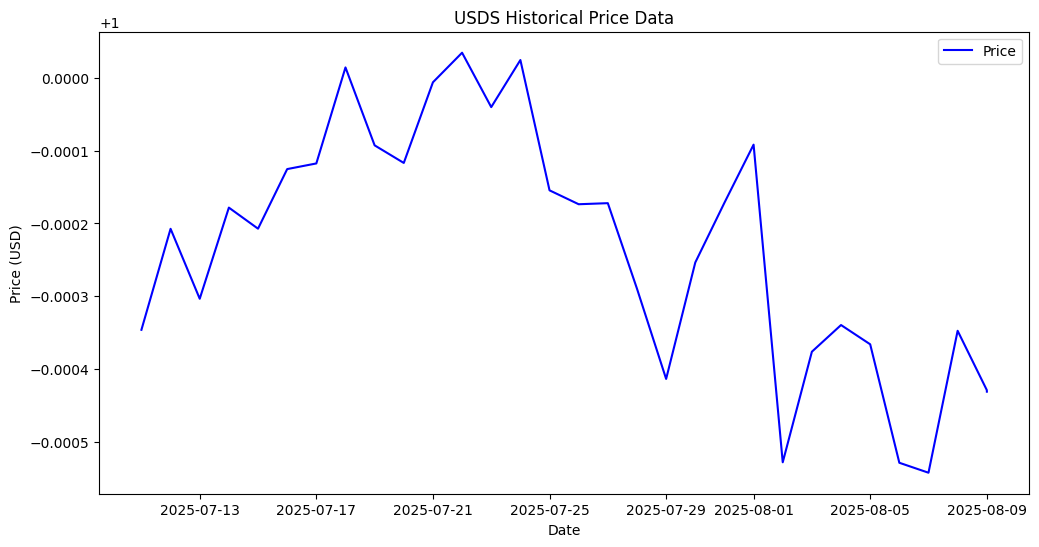

In [40]:
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Plotting the historical price data
plt.figure(figsize=(12, 6))  # Setting the figure size
plt.plot(historical_data['timestamp'], historical_data['price'], label='Price', color='blue')  # Plotting the price data
plt.title(f'{coin.upper()} Historical Price Data')
plt.xlabel('Date')  # Setting the x-axis label
plt.ylabel('Price (USD)')  # Setting the y-axis label
plt.legend()

### Fetch Historical chart data within a specific time range

In [41]:
# Public API endpoints allow you to fetch historical data for a specific coin within last 365 days.

coin = 'bitcoin'  # Example coin ID, you can change this to any valid coin ID
params = {
    'vs_currency': 'usd',  # The target currency for the market data
    'from': '2025-01-01',  # Start date for the historical data (YYYY-MM-DD)
    'to': '2025-07-31'  # End date for the historical data (YYYY-MM-DD)
}

r = requests.get(f'{coingecko_url}/coins/{coin}/market_chart/range', headers=headers, params=params)
r.raise_for_status()
data = r.json()  # Parsing the JSON response
print(f'API Response:\n{json.dumps(data, indent=4)}')  # Displaying the API response in a formatted JSON structure

API Response:
{
    "prices": [
        [
            1735689600000,
            93507.85874741491
        ],
        [
            1735776000000,
            94384.1761153871
        ],
        [
            1735862400000,
            96852.14681235075
        ],
        [
            1735948800000,
            98084.34279280754
        ],
        [
            1736035200000,
            98256.73876849933
        ],
        [
            1736121600000,
            98364.58946599838
        ],
        [
            1736208000000,
            102229.39453189743
        ],
        [
            1736294400000,
            96952.09886774956
        ],
        [
            1736380800000,
            95016.71440989176
        ],
        [
            1736467200000,
            92376.27578346101
        ],
        [
            1736553600000,
            94736.6267420969
        ],
        [
            1736640000000,
            94559.55167224213
        ],
        [
            17367264000

In [42]:
data.keys()  # Displaying the keys of the data dictionary to understand its structure

dict_keys(['prices', 'market_caps', 'total_volumes'])